# Group 16 Final Report

Group Members: Merry Liu, Wendy Liao, Chenwen Zhang, Terence Fung

## Introduction 

### a. Background Information

We will be working with data collected from the PLAICraft project by the Pacific Laboratory for Artificial Intelligence (PLAI) research group that is led by Frank Wood. PLAICraft is a research data collection project for advanced embodied AI research using a Minecraft server that records players' actions as they play through the world (Pacific Laboratory for Artificial Intelligence , n.d.). A project like this requires resources such as software licenses and server hardware to run, thus knowing who to target when recruiting participants is important. 
 
### b. Question

For our project, we will be addressing broad question #1 to help with knowing who to target when looking for players/participants: **What player characteristics and behaviours are most predictive of subscribing to a game-related newsletter, and how do these features differ between various player types?** 

The specific question we have formulated to investigate: **Are age and played_hours predictors of a players subscription status to a game-related newsletter?** 

### c. Data Description

We are using only 1 (players.csv) of the 2 datasets provided, as only 1 is necessary to answer our question.

**Players** 

- total 7 variables
- total 196 observations (participants)
- one of the Age observations contains an "NA"

  
| Variable  | Data Type | Meaning|
| --------- | --------- |--------|
|experience | chr  |participant level of experience in Minecraft (Beginner, Amateur, Regular, Veteran,Pro)| 
|subscribe  |  lgl |whether or not (True/False) participant is subscribed to game-related newsletter|
|hashedEmail|chr|participant email that has been hashed |
| played_hours| dbl |hours played in Minecraft  |
|name  |   chr  |  Participant name |
|gender|chr|Gender of participant |
|Age | dbl |participant age|

- **Issues**
    1. variable name hashedEmail is not in snake_case
    2. Age variable is not in snake_case (very small issue, however, inconsistent)
    3. "NA" in Age variable 


## Methods & Results 

- describe the methods you used to perform your analysis from beginning to end that narrates the analysis code.
- your report should include code which:
      - loads data
    - wrangles and cleans the data to the format necessary for the planned analysis 
    - performs a summary of the data set that is relevant for exploratory data analysis related to the planned analysis 
    - creates a visualization of the dataset that is relevant for exploratory data analysis related to the planned analysis
    - performs the data analysis
    - creates a visualization of the analysis
    - note: all figures should have a figure number and a legend 


Before we can begin anyting, the *repr* and *tidyverse* package is loaded into jupyter for obtaining the tools necessary for data analysis and wrangling. The *tidymodels* package contains tools for making and using models, which we use for our data analysis. 

In [2]:
library(repr)
library(tidyverse)
library(tidymodels)
options(repr.matrix.max.rows = 5) #limited dataframes to only show the first 5 rows for legibility

<<<<<<< local
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()

### 1. Loading data

In [3]:
players_url <- "https://raw.githubusercontent.com/whendyliow/ds_100_group/refs/heads/main/data/players.csv"
players <- read_csv(players_url) 

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


### 2. Wrangles and cleans the data

We tidied the data by making the variable **subscribe** from a logical vector type to a factor vector type as this is our response variable. Additionally, we renamed **hashed_Email** and **Age** to fit lower snake case and we also took out any observations with NA in them. 

In [ ]:
players_tidy <- players |>
    mutate(subscribe=as_factor(subscribe))|>
    rename(hashed_email = hashedEmail, 
               age = Age) |>
    drop_na()

players_tidy

experience,subscribe,hashed_email,played_hours,name,gender,age
<chr>,<fct>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
⋮,⋮,⋮,⋮,⋮,⋮,⋮
Amateur,FALSE,d572f391d452b76ea2d7e5e53a3d38bfd7499c7399db299bd4fedb06a46ad5bb,0.0,Dylan,Prefer not to say,57
Amateur,FALSE,f19e136ddde68f365afc860c725ccff54307dedd13968e896a9f890c40aea436,2.3,Harlow,Male,17


### 3. Summary Statistics


| Variable      | Mean    | Min | Max |
| ------------- | ------- | --- | --- |
| played_hours  | 5.9   |0    |223.1|
| Age           |  21.14  | 9   | 58  |


In [ ]:
# age min and max
players_age_summary <- players_tidy |>
    select(age)|>
    summarize(players_age_max=max(age,na.rm=TRUE),
              players_age_min=min(age,na.rm=TRUE))

players_age_summary

# player_hours min and max
played_hours_summary <- players_tidy |>
    select(played_hours)|>
    summarize(played_hours_min=min(played_hours,na.rm=TRUE),
              played_hours_max=max(played_hours,na.rm=TRUE))

played_hours_summary

# age and played_hours means 
players_mean <- players_tidy |>
    select(played_hours,age)|>
    summarize(played_hours_avg=mean(played_hours),
              players_age_avg=mean(age))|>
    mutate(played_hours_avg = round(played_hours_avg, 2),
           players_age_avg = round(players_age_avg, 2))

players_mean

players_age_max,players_age_min
<dbl>,<dbl>
58,9


played_hours_min,played_hours_max
<dbl>,<dbl>
0,223.1


played_hours_avg,players_age_avg
<dbl>,<dbl>
5.9,21.14


### 4. Exploratory Visualizations

<<<<<<< local


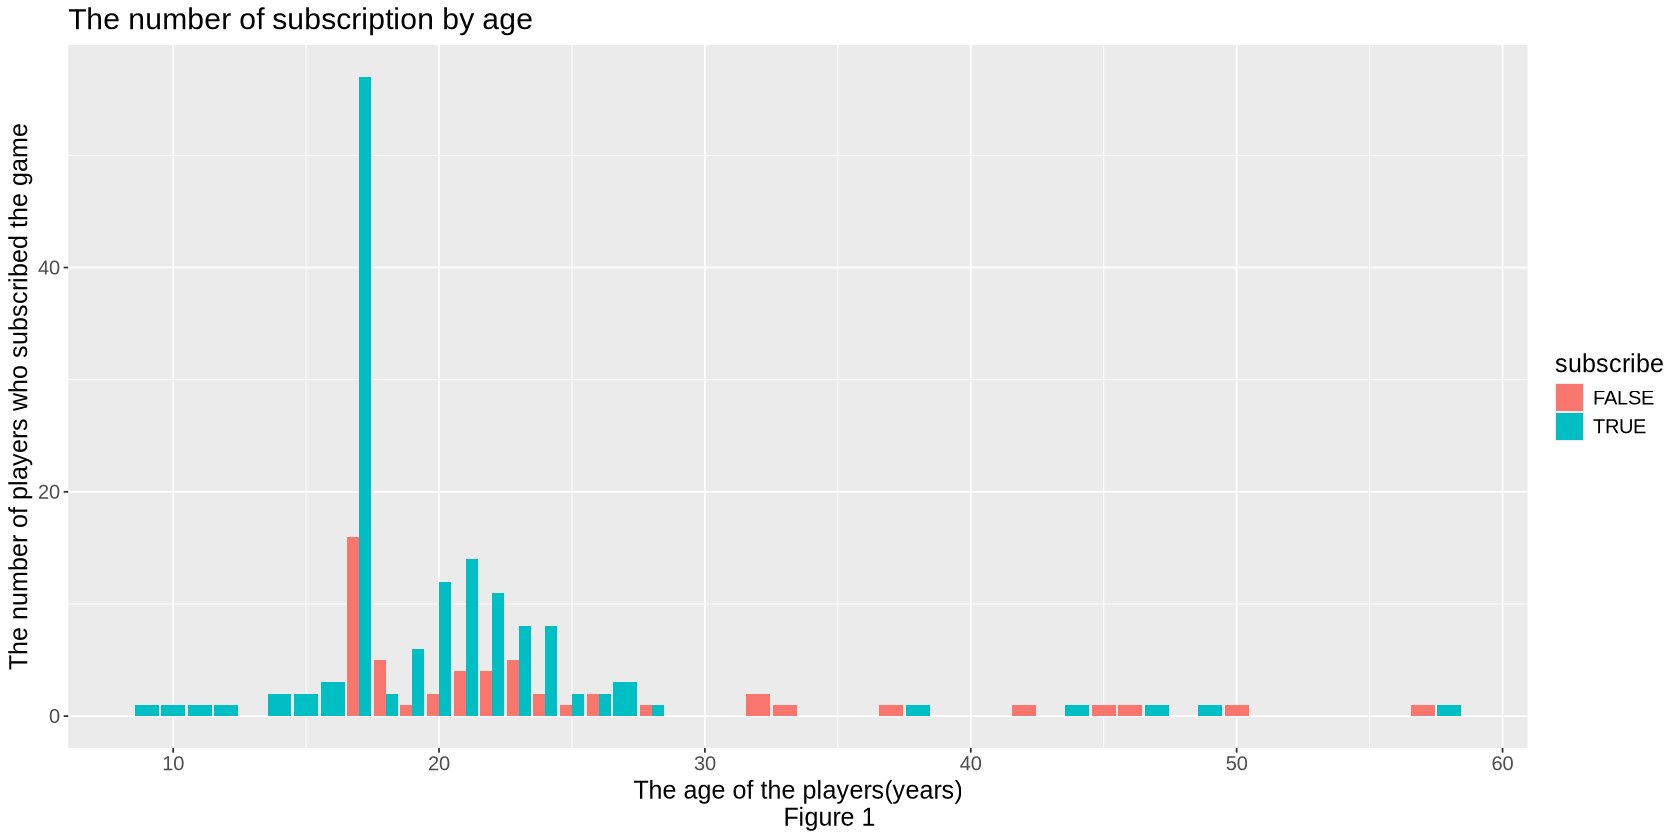

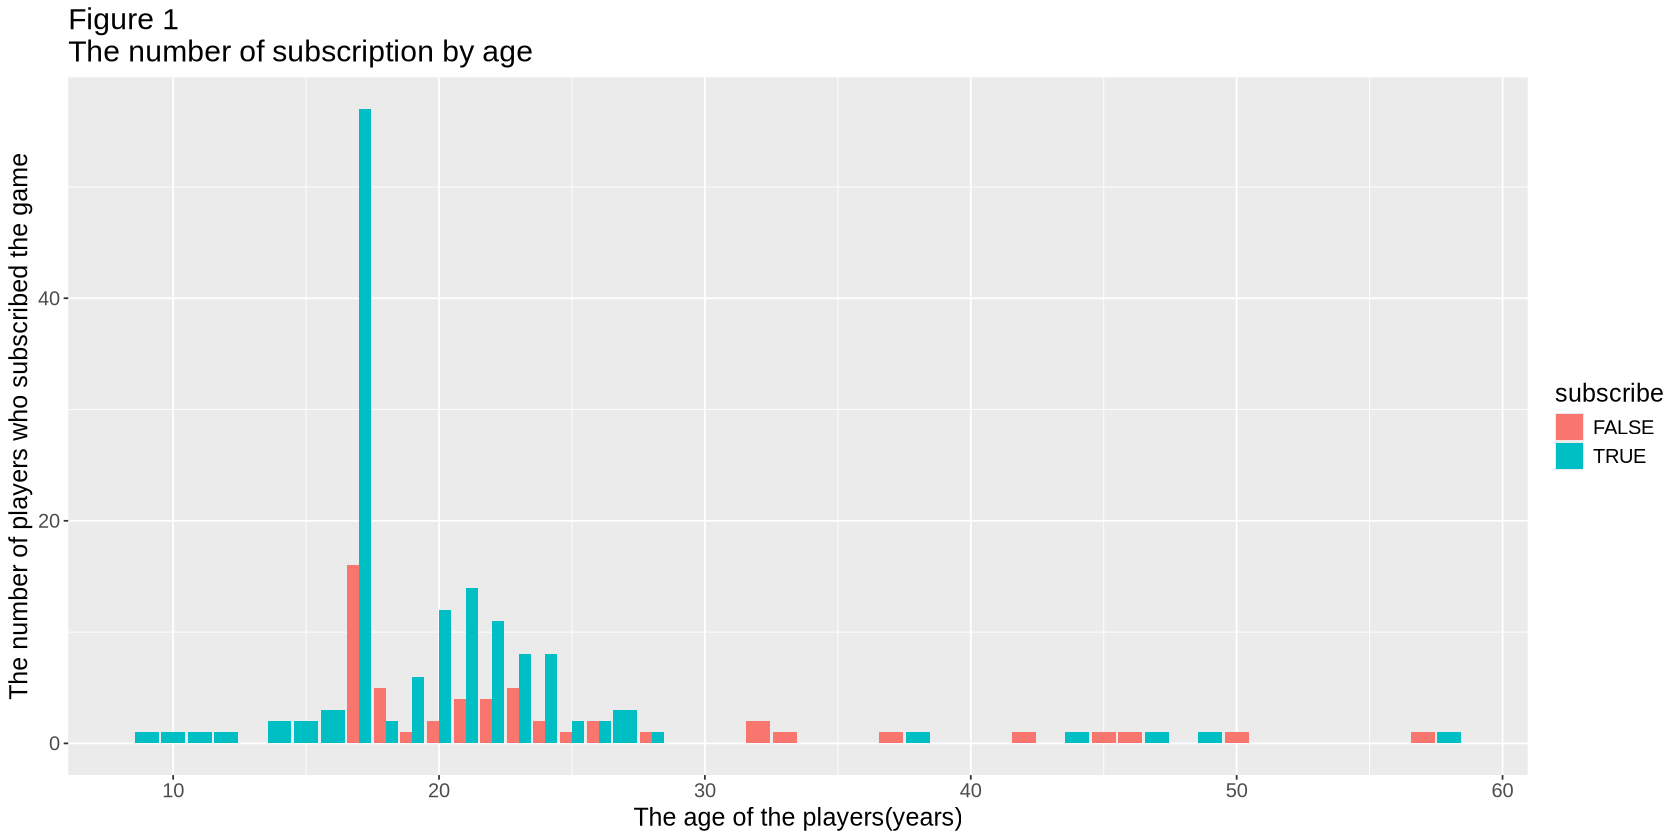

>>>>>>> remote


In [ ]:
#exploratory visualization #1
options(repr.plot.height=7, repr.plot.width=14)

players_age_plot_1 <- players_tidy |>
select(age,subscribe)|>
ggplot(aes(x = age, fill = subscribe)) + 
   geom_bar(position = "dodge") +
   scale_x_continuous(breaks = seq(0,60,by=10))+
   labs(x = "The age of the players(years)" ,
        y = "The number of players who subscribed the game",
        title = "Figure 1
The number of subscription by age")+
   theme(text=element_text(size=15))

players_age_plot_1

Figure 1:

This bar chart compares the subscription status of players across different ages. It is evident that a peak appear at age 17,where have the highest number of both subscribed and non-subscribed players, representing by far the highest figures. This indicates that 17-year-old players represent the largest portion of all the players across different ages in the dataset.

As for young players, particularly those between 15-25 years old, the number of subscription are generally higher compared to older players.

In contrast, for players between age 9 to 12, and over 30-year-old have very low counts in both subscribed and non-subscribed players.

Overall, the graph illustrates that the younger players, especially around age 17, account for the majority of the dataset. The older age groups show limited subscription behavior due to their smaller population size. Same goes for players between age 9 to 12.

<<<<<<< local


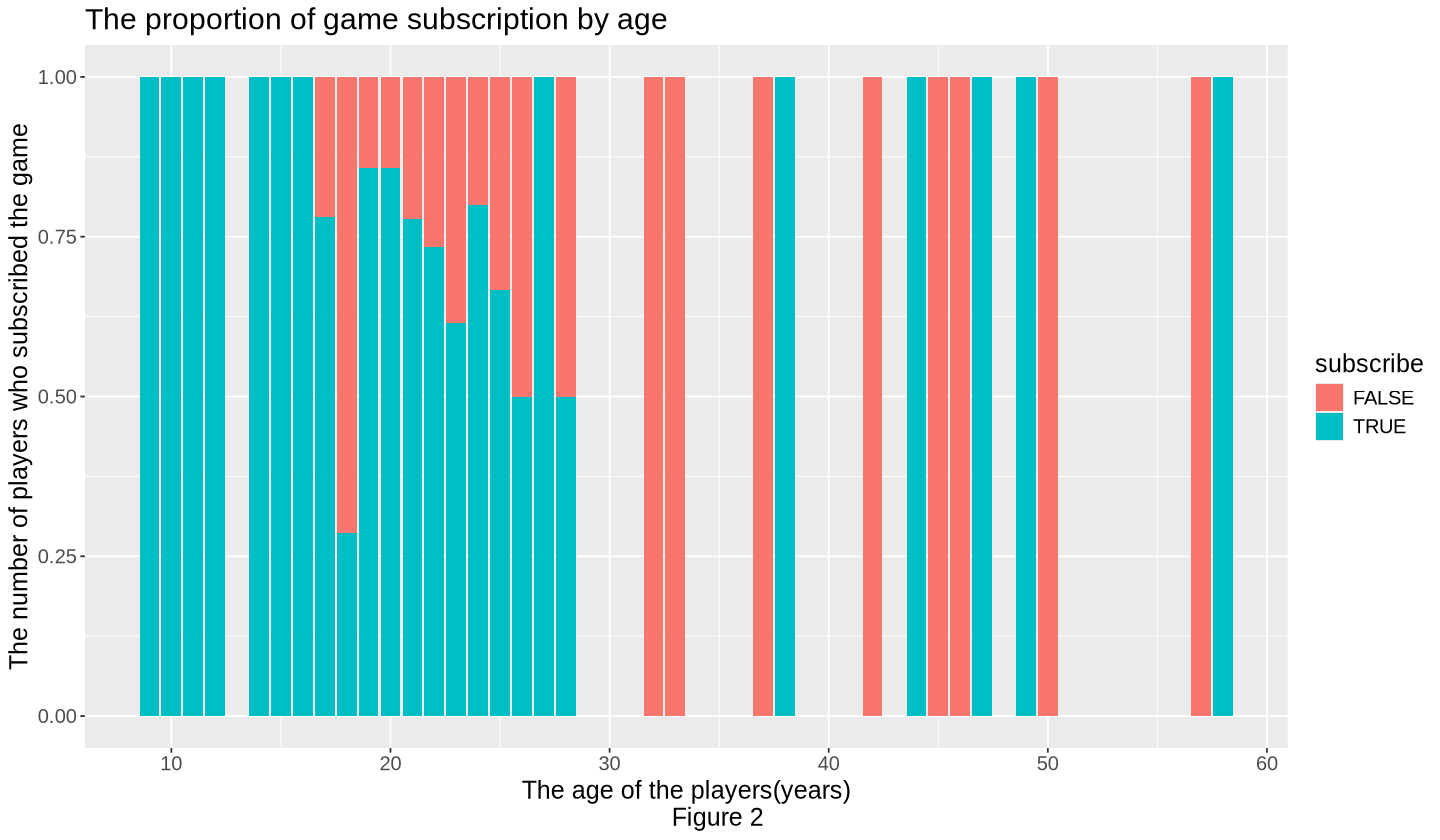

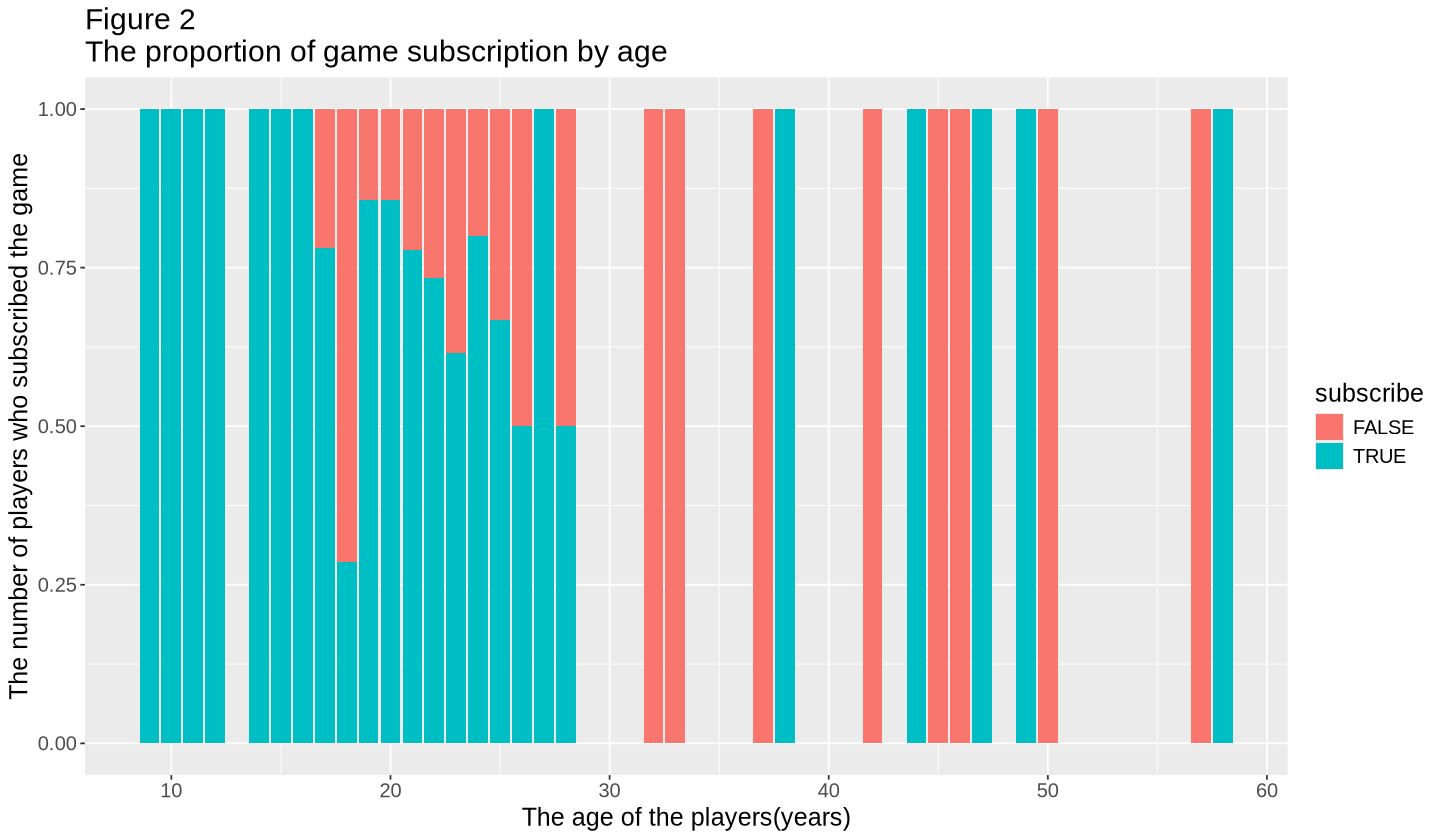

>>>>>>> remote


In [ ]:
# exploratory visualization #2 
options(repr.plot.width=12, repr.plot.height=7)

players_plot_2 <- players_tidy |>
select(age,subscribe)|>
ggplot(aes(x = age, fill = subscribe)) + 
   geom_bar(position = "fill") +
   scale_x_continuous(breaks = seq(0,60,by=10))+
   labs(x = "The age of the players(years)" ,
        y = "The number of players who subscribed the game",
        title = "Figure 2
The proportion of game subscription by age")+
   theme(text=element_text(size=15))

players_plot_2

Figure 2:
  
This bar chart compares the proportion of players who subscribed across different age groups. It is clear that players around or under 15 years old all subscribed the game. For younger players (under 30), they are generally more likely to subscribe, but also a lot of them did not, especially those aged 18 that only has approximately 30% subscribed to the game.

By contrast, players above 30 display a fairly balanced subscription patterns, with roughly equal subscribed and non-subscribed.

Overall, while younger players include many non-subscribers, they also make up the majority of the dataset, representing strong engagement potential among players aged between 9 to 28.

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.
<<<<<<< local


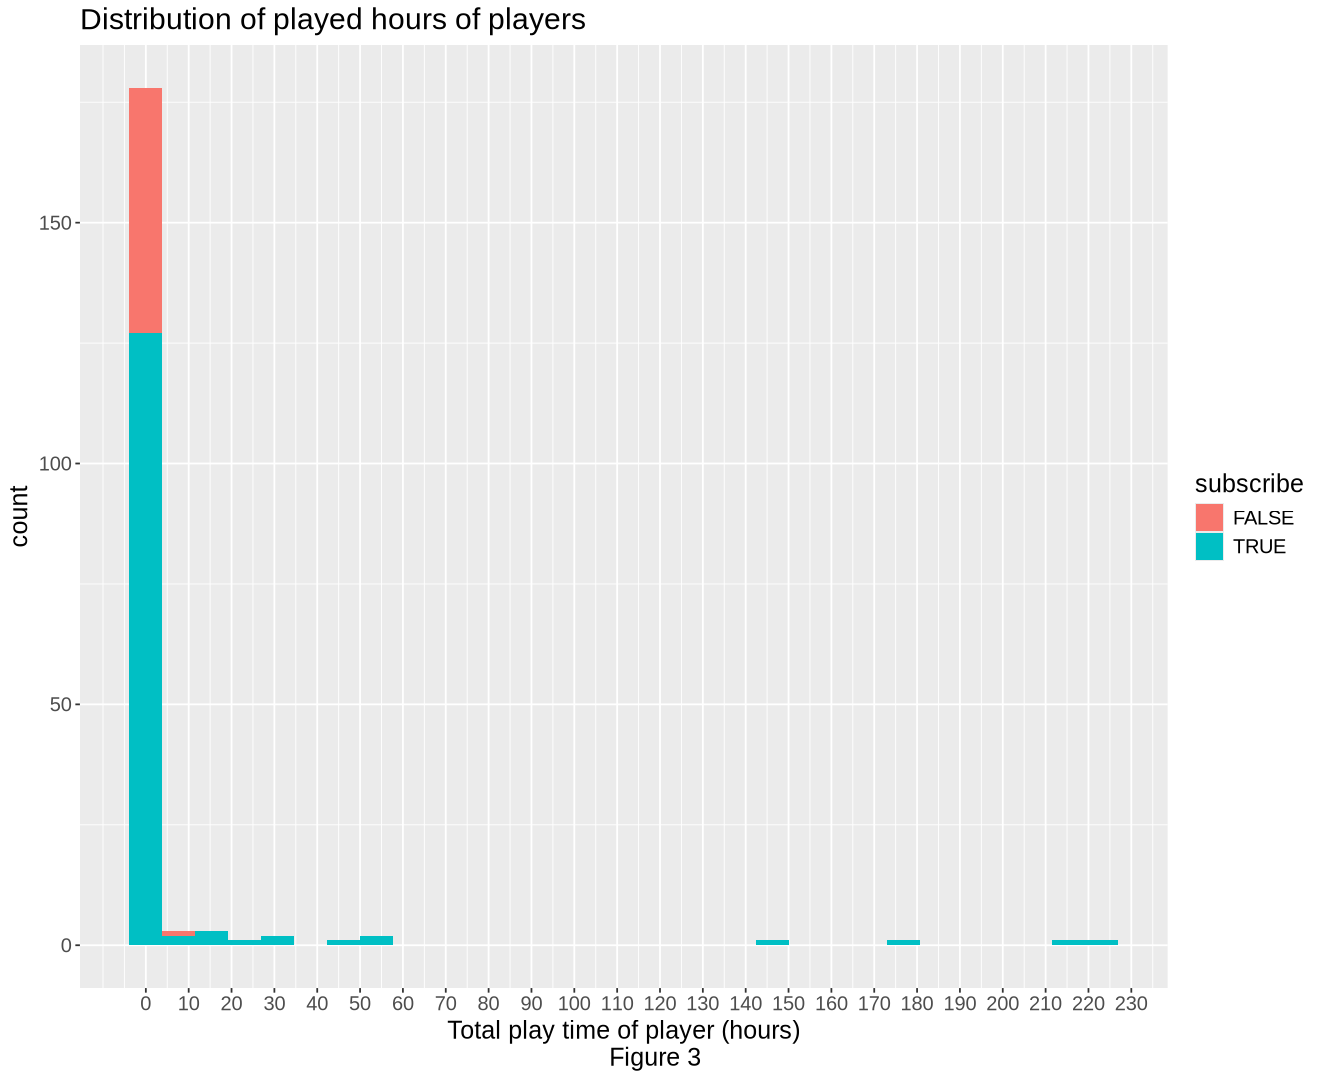

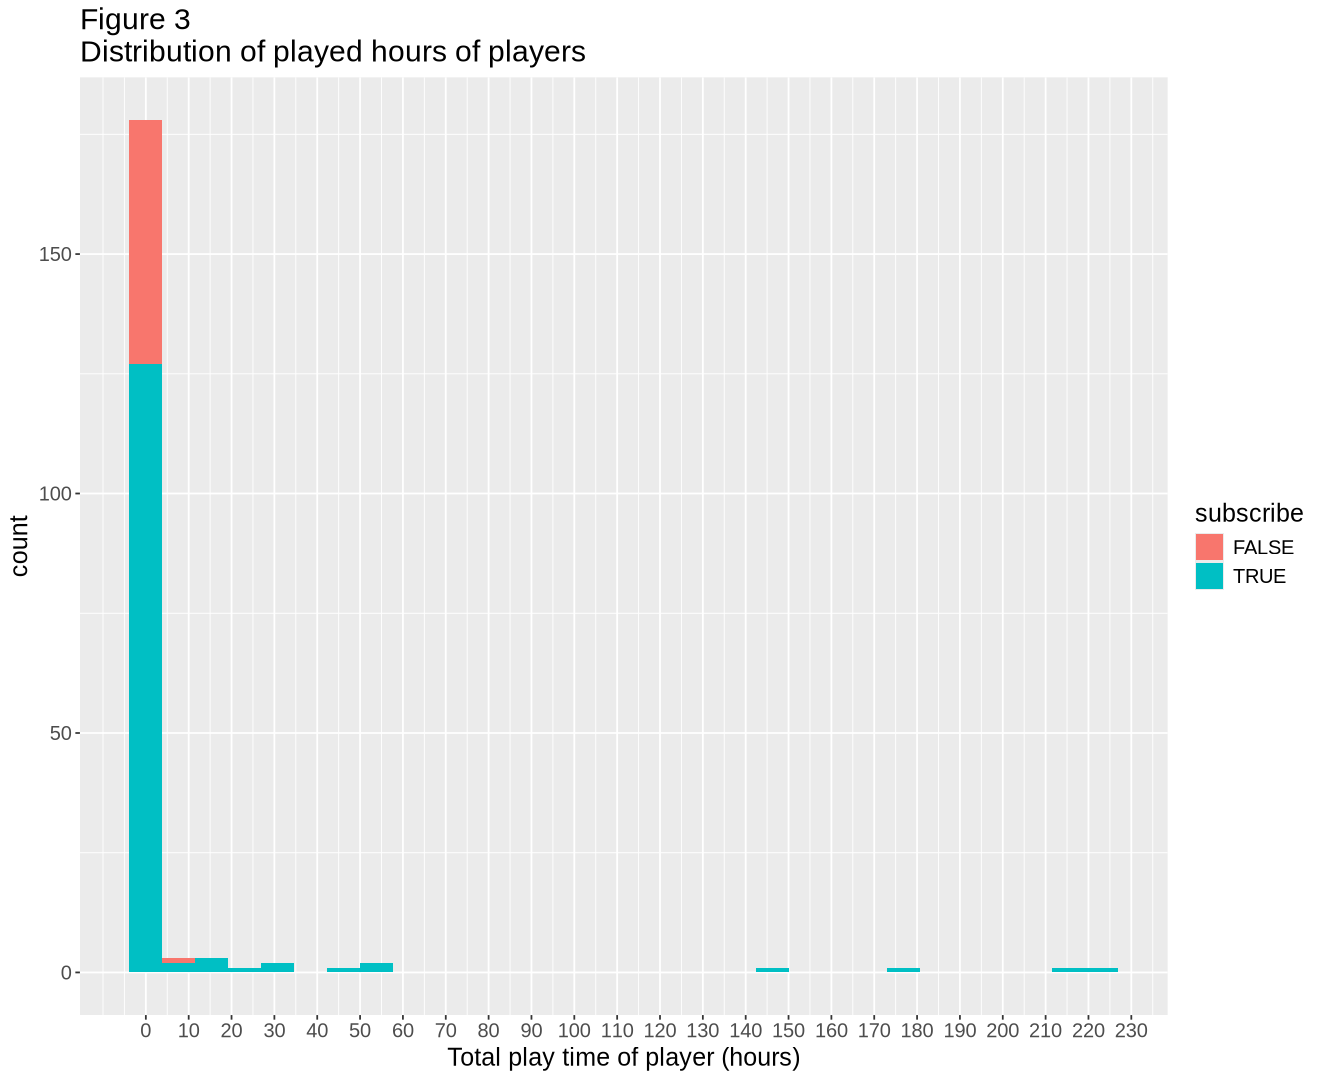

>>>>>>> remote


In [ ]:
#exploratory visualization #3 
options(repr.plot.width= 11, repr.plot.height= 9)

players_hrs_plot <- players_tidy |>
    ggplot(aes(x = played_hours, fill = subscribe)) +
    geom_histogram() +
    labs(x = "Total play time of player (hours)", 
         color = "Whether a player is subscribed", 
         title = "Figure 3
Distribution of played hours of players") +
scale_x_continuous(breaks = seq(0,250,by=10))+
    theme(text = element_text(size=15))

players_hrs_plot

Figure 3:
  
This histogram shows the distribution of the played hours of players. According to the histogram, all players with more than 10 hours played time subscribed to the game, representing players who spend more time playing are more likely to subscribe indeed.

However, as for those players with 10 or fewer player hours, approximately 70% also subscribed, suggesting that many short players still subscribed the game.

Overall, whereas played hours affects the subscription behavior in some way, they do not seem to be the dominant factor driving whether a player subscribe.

### 5. Data Analysis

Next, create a scatterplot to explore the relationship between the predictors and the target variable.

<<<<<<< local


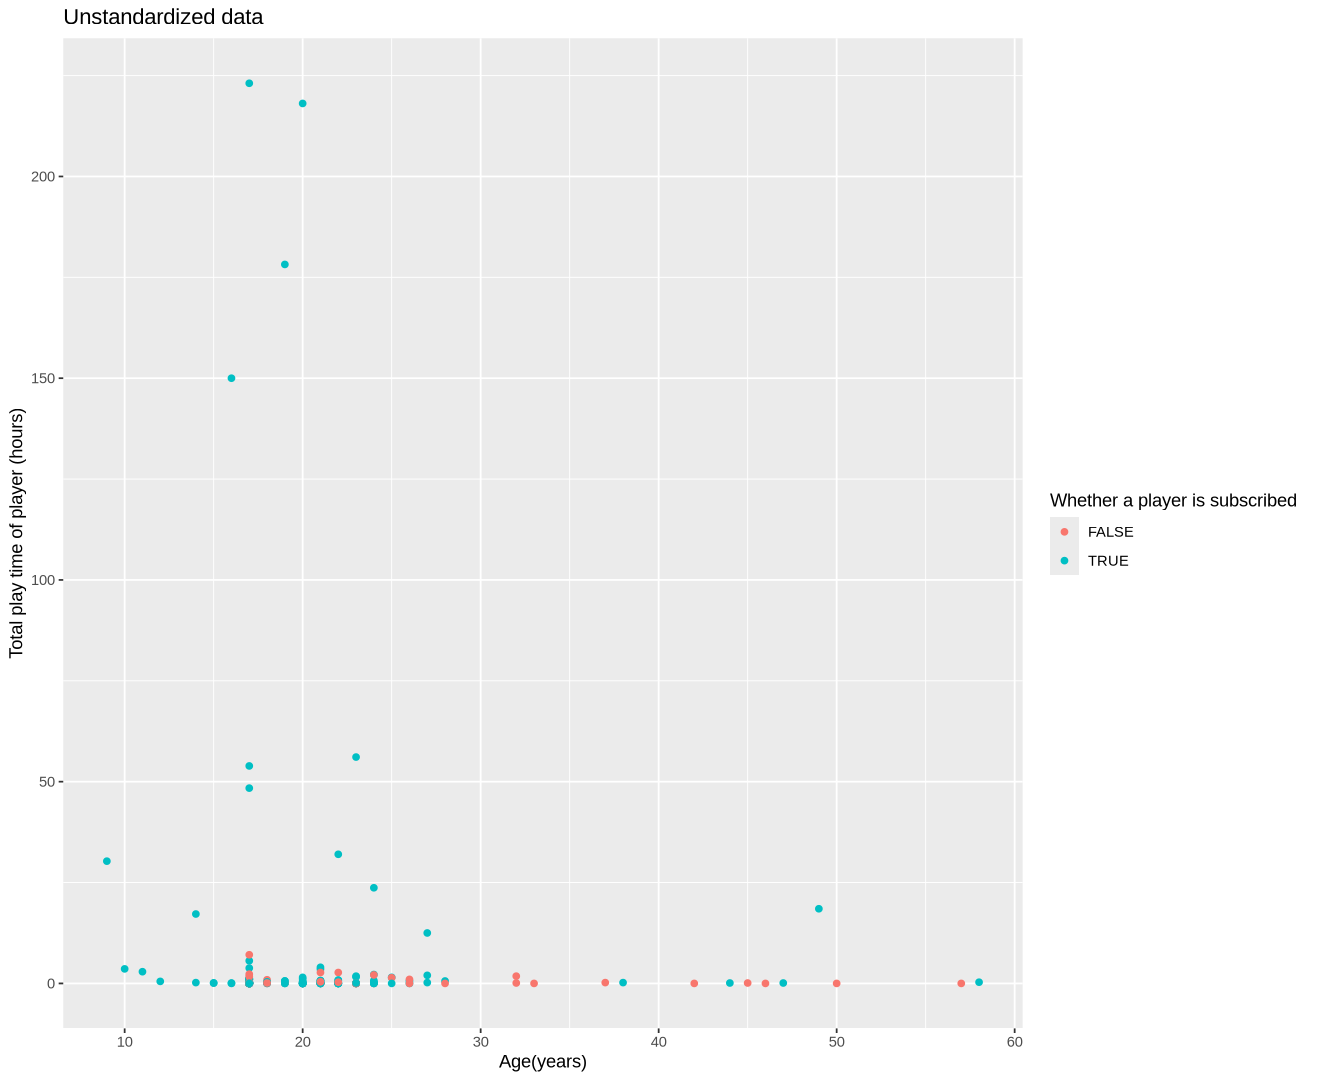

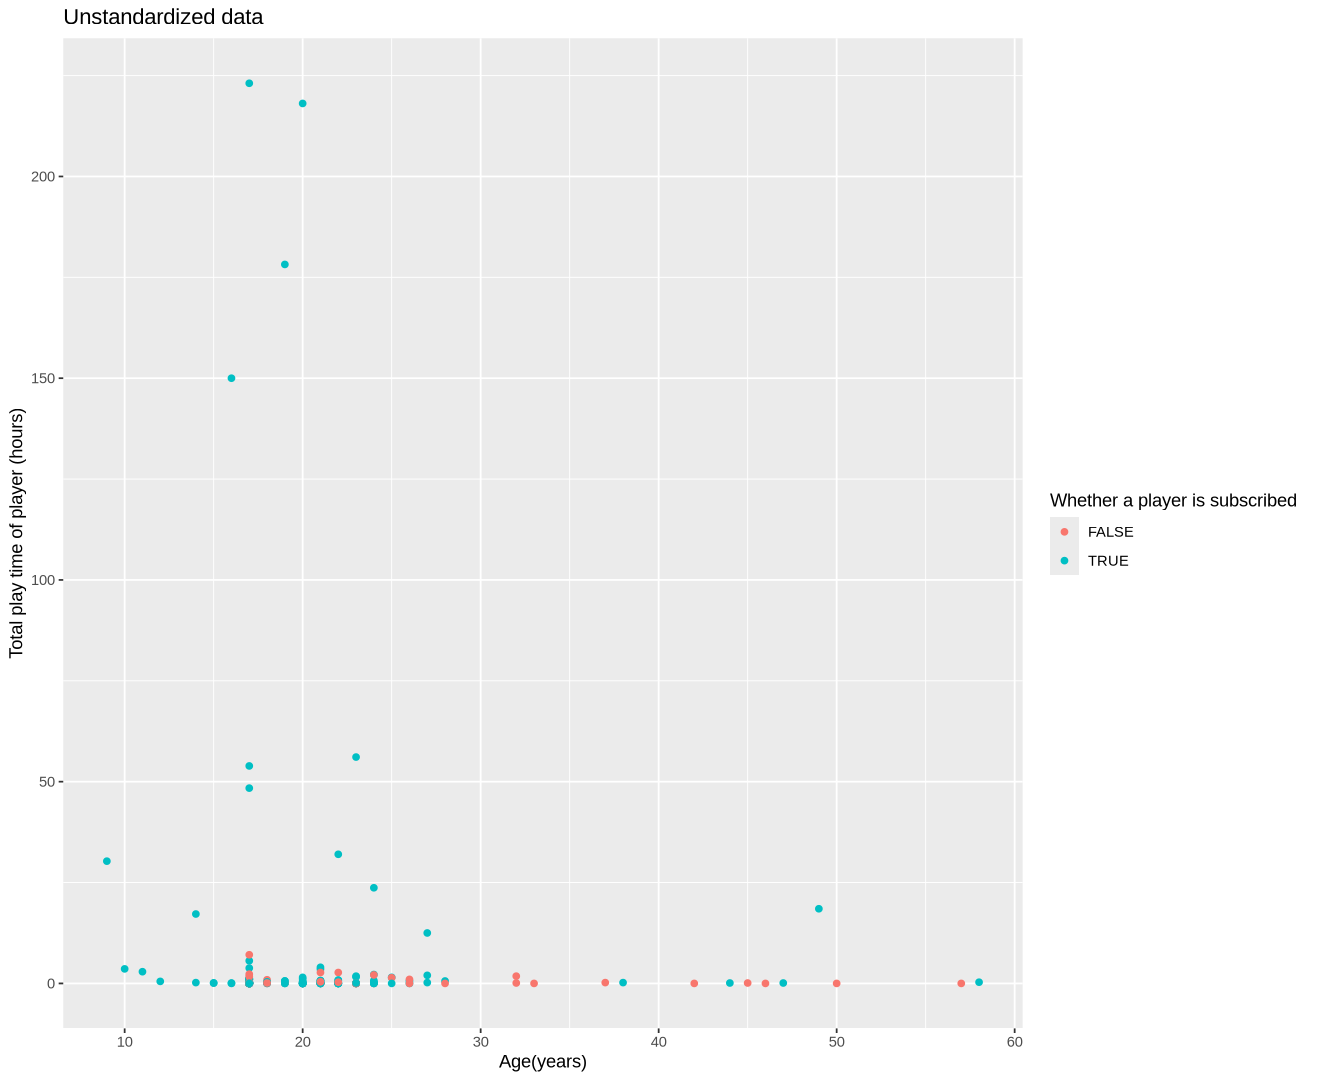

>>>>>>> remote


In [ ]:
ggplot(players_tidy,aes(x= age, y= played_hours, color = subscribe))+
    geom_point()+
    labs(x="Age(years)", 
         y="Total play time of player (hours)",
         color="Whether a player is subscribed",
        title="Unstandardized data")

Next, split the data into training data and testing data. 

I will use 75% of the data for training and 25% for testing.The subset of training data used for evaluation is the validation set. And then I will use it for cross-validation.

In [ ]:
set.seed (236) 

players_split <- initial_split(players_tidy, prop = 0.75, strata=subscribe)

players_train <- training(players_split)
players_test <- testing(players_split)

Next, we use cross-validation on the training data set to select which k is the most optimal for our data set for k-nn classification.

we will :
- Create a recipe that uses all predictors and a model specification with tuning on the number of neighbours 
- Perform a 5-fold cross-validation on the training set
- Create a workflow analysis with your recipe and model specification. 
- Collect the metrics from the workflow analysis
- Plot the accuracy vs k, assign this plot to an object called cross_val_plot

In [ ]:
set.seed(9999) 

players_recipe <- recipe(subscribe ~ age + played_hours, data = players_train)|>
     step_scale(all_predictors()) |>
     step_center(all_predictors())

players_vfold <- vfold_cv(players_train, v = 5, strata = subscribe)

players_model <- nearest_neighbor(weight_func="rectangular", neighbors = tune())|>
   set_engine("kknn")|>
   set_mode("classification")

k_vals <- tibble(neighbors = seq(from = 1, to = 50, by = 1))

players_workflow <- workflow()|>
    add_model(players_model)|>
    add_recipe(players_recipe)|>
    tune_grid(resamples = players_vfold, grid = k_vals) |>
    collect_metrics()

players_workflow

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.5291297,5,0.04954985,Preprocessor1_Model01
1,roc_auc,binary,0.5294913,5,0.06679898,Preprocessor1_Model01
2,accuracy,binary,0.5222332,5,0.04802013,Preprocessor1_Model02
⋮,⋮,⋮,⋮,⋮,⋮,⋮
50,accuracy,binary,0.7311494,5,0.005037841,Preprocessor1_Model50
50,roc_auc,binary,0.5332096,5,0.034131249,Preprocessor1_Model50


In [ ]:
accuracies <- players_workflow |>
  filter(.metric == "accuracy")

accuracies

neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
1,accuracy,binary,0.5291297,5,0.04954985,Preprocessor1_Model01
2,accuracy,binary,0.5222332,5,0.04802013,Preprocessor1_Model02
3,accuracy,binary,0.5555501,5,0.07411636,Preprocessor1_Model03
⋮,⋮,⋮,⋮,⋮,⋮,⋮
49,accuracy,binary,0.7311494,5,0.005037841,Preprocessor1_Model49
50,accuracy,binary,0.7311494,5,0.005037841,Preprocessor1_Model50


<<<<<<< local


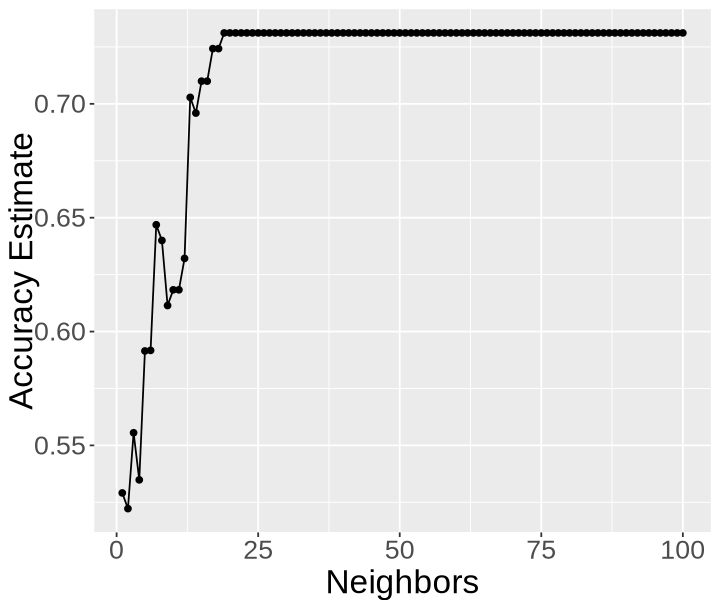

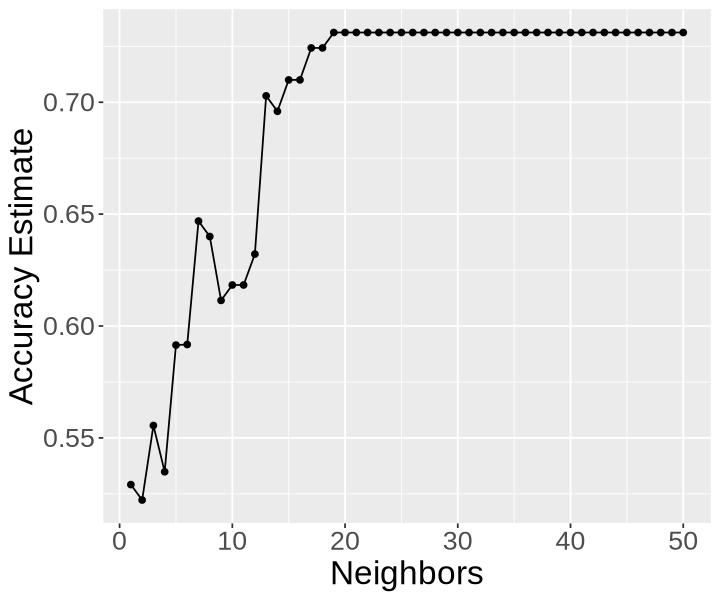

>>>>>>> remote


In [ ]:
options(repr.plot.height = 5, repr.plot.width = 6)

cross_val_plot <- ggplot(accuracies, aes(x = neighbors, y = mean)) +
                  geom_point() +
                  geom_line() +
                  labs(x = 'Neighbors', y = 'Accuracy Estimate') +
                  theme(text = element_text(size = 20)) 

cross_val_plot

In [ ]:
best_k <- accuracies |>
        arrange(desc(mean)) |>
        head(1) |>
        pull(neighbors)
best_k

[1] 19

A K of 19 gives us the best accuracy which is approximately 0.75. We can be sure as cross-validation attempts to give us an unbiased estimate of the k by splitting the data in multiple parts and using the average of the multiple splits as the estimate.

### Evaluating on the test set

In [ ]:
set.seed(740) 

players_recipe <- recipe(subscribe ~ age + played_hours, data = players_train)|>
     step_scale(all_predictors()) |>
     step_center(all_predictors())

players_model <- nearest_neighbor(weight_func="rectangular", neighbors = best_k)|>
   set_engine("kknn")|>
   set_mode("classification")

players_fit <- workflow() |>
  add_recipe(players_recipe) |>
  add_model(players_model) |>
  fit(data = players_train)

players_fit

══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
2 Recipe Steps

• step_scale()
• step_center()

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(19,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.2827586
Best kernel: rectangular
Best k: 19

In [35]:
set.seed(740) 

players_test_predictions <- predict(players_fit, players_test) |>
  bind_cols(players_test)

players_test_predictions_accuracy <- players_test_predictions |>
  metrics(truth = subscribe, estimate = .pred_class) |>
  filter(.metric == "accuracy")

players_test_predictions_conf_mat <- players_test_predictions |>
    conf_mat(truth=subscribe, estimate= .pred_class)

players_test_predictions_accuracy
players_test_predictions_conf_mat

players_test_precision <- 34/(34+11)
players_test_precision

probability_random_positive <- sum(players_tidy$subscribe == "TRUE")/nrow(players)
probability_random_positive

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.7346939


          Truth
Prediction FALSE TRUE
     FALSE     2    2
     TRUE     11   34

[1] 0.7555556

[1] 0.7244898

| Metrics  | Object in the program relevant to the metric | Value|
| --------- | --------- |--------|
|probability of getting a subscriber when randomly drawing from the population | probability_random_positive| 0.724489795918367|
|Model precision  | players_test_precision  | 0.755555555555556|0.755555555555556

Our accuracy was about 73%, this means that about 27% of the time our classifier makes a mistake which is likely too low. For the improvements, we might want to include more data. We could also explore if there are additional parameters to tune that could improve model performance, or a different model altogether.

Our precision is about 76%. this means that when our model predict a user to be a subscriber, it has a 76% to be correct. This probability is too low as the probability to randomly draw a subscriber from the population is 72%, meaning that our model is only 4 percentage points more accurate than if we just assign everyone as a subscriber.

## Discussion 
- chloe: summarize what you found
- merry: discuss whether this is what you expected to find
- terence: discuss what impact could such findings have
- wendy: discuss what future questions could this lead to



### 1. Summary of data analysis

Make a scatterplot of scaled age on the horizontal axis and scaled played hours on the vertical axis. 

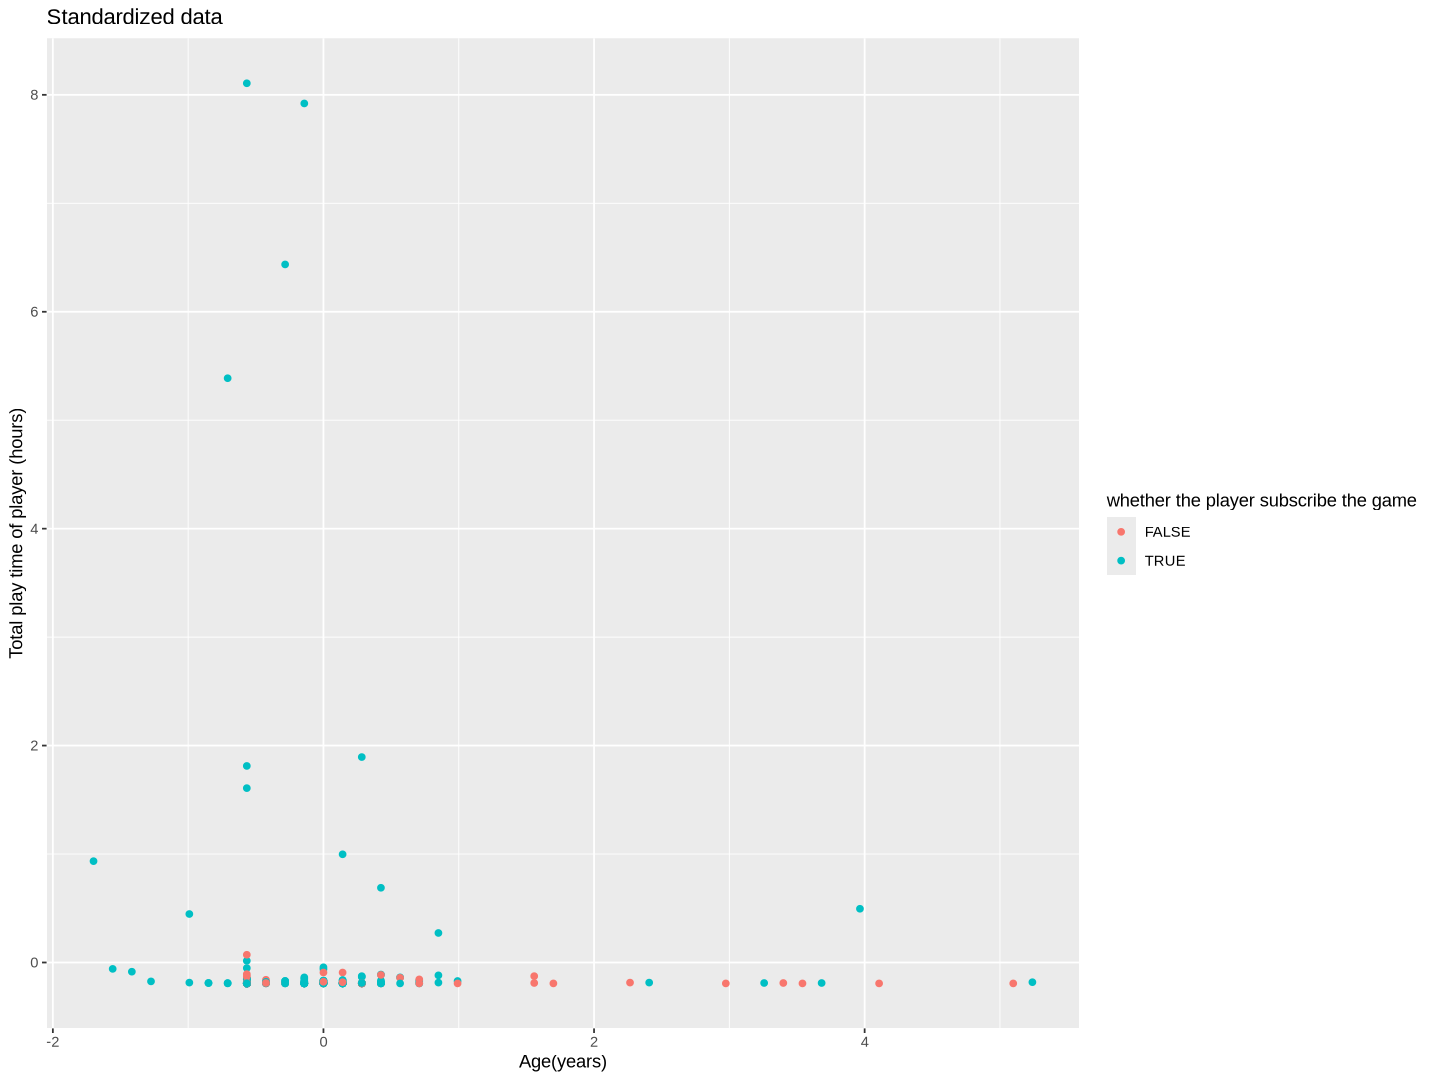

In [ ]:
players_scaled <- players_recipe |>  
                           prep() |> 
                           bake(players_tidy)

players_scaled_plot <- players_scaled |>
ggplot(aes(x=age, y=played_hours, color=subscribe))+
geom_point()+

labs(x="Age(years)", 
     y="Total play time of player (hours)",
     color="whether the player subscribe the game",
     title="Standardized data")

players_scaled_plot

#### 1.1 method
- The classification is appropriate because the response variable (subscribe) is a categorical type.
- The K-nearest neighbors (KNN) algorithm can be used here because it can use data directly to form the class by measuring the proximity to neighboring points to determine the class of a new sample.
- K-nearest neighbors (KNN) algorithm requires a few assumptions about what the data must look like. It can essentially captures any kind of shape of data for a class.
- Use cross-validation to give a better choice of the number of neighbors K for the overall set of training data. It helps assess the model's performance across different subsets of the data, This helps ensure that the model's performance is not overly dependent on a specific training-test split, and it aids in obtaining a more reliable evaluation of its accuracy and effectiveness on unseen data.


#### 1.2  strengths and weaknesses for K-nearest neighbors classification
Strengths: 
- is a simple, intuitive algorithm,
- requires few assumptions about what the data must look like, and
- works for binary (two-class) and multi-class (more than 2 classes) classification problems.

Weaknesses: 
- becomes very slow as the training data gets larger,
- may not perform well with a large number of predictors, and
- may not perform well when classes are imbalanced.

## References 
Pacific Laboratory for Artificial Intelligence . (n.d.). Plaicraft. PLAICraft. https://plaicraft.ai/ 